# Phase 1: Exploratory Data Analysis (EDA)
## Advanced Facial Emotion Recognition Project

**Objectives:**
1. Load and explore FER2013, CK+48, and JAFFE datasets
2. Analyze class distributions
3. Assess image quality
4. Generate visualizations

In [1]:
# Install required packages (run once)
import sys
!{sys.executable} -m pip install typing_extensions --upgrade --quiet
!{sys.executable} -m pip install torch torchvision --quiet
!{sys.executable} -m pip install opencv-python==4.8.0.76 scikit-learn scikit-image pillow --quiet
print("✓ All packages installed!")

✓ All packages installed!


In [2]:
# Imports
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from tqdm import tqdm
import json

from src.utils.config import Config, setup_seed
from src.utils.visualization import (
    plot_class_distribution,
    plot_multi_dataset_distribution,
    plot_sample_images,
    plot_quality_metrics
)
from src.data.dataset_loader import FER2013Dataset, CKPlusDataset, JAFFEDataset

config = Config('../config/config.yaml')
setup_seed(config.get('project.random_seed'))

%matplotlib inline
print('✓ Setup complete!')

✓ Setup complete!


## 1. Load Datasets

In [3]:
emotions = config.get('emotions.classes')
print(f'Emotion classes: {emotions}')

import os
PROJECT_ROOT = Path('..').resolve()
print(f'CWD: {os.getcwd()}')
print(f'Project root: {PROJECT_ROOT}')

# FER2013
print('\nLoading FER2013...')
try:
    fer_path = str(PROJECT_ROOT / config.get('data.fer2013.path'))
    fer_train = FER2013Dataset(fer_path, split='train')
    fer_test  = FER2013Dataset(fer_path, split='test')
    fer_val   = fer_test  # FER2013 has no separate val split
    print(f'✓ Train: {len(fer_train)}, Val: {len(fer_val)}, Test: {len(fer_test)}')
except Exception as e:
    print(f'✗ Error: {e}')
    fer_train = fer_val = fer_test = None

# CK+48
print('\nLoading CK+48...')
try:
    ckplus = CKPlusDataset(str(PROJECT_ROOT / config.get('data.ckplus.path')))
    print(f'✓ Total: {len(ckplus)}')
except Exception as e:
    print(f'✗ Not available: {e}')
    ckplus = None

# JAFFE
print('\nLoading JAFFE...')
try:
    jaffe = JAFFEDataset(str(PROJECT_ROOT / config.get('data.jaffe.path')))
    print(f'✓ Total: {len(jaffe)}')
except Exception as e:
    print(f'✗ Not available: {e}')
    jaffe = None


Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
CWD: /Users/nyanwaiphyo/Signature Project/fer-project/notebooks
Project root: /Users/nyanwaiphyo/Signature Project/fer-project

Loading FER2013...
Loading from: /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/FER2013/train


Loaded 28709 images from /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/FER2013/train
Loading from: /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/FER2013/test


Loaded 7178 images from /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/FER2013/test
✓ Train: 28709, Val: 7178, Test: 7178

Loading CK+48...
Loading from: /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/CK+48/ck+


Loaded 981 images from CK+
✓ Total: 981

Loading JAFFE...
Loading from: /Users/nyanwaiphyo/Signature Project/fer-project/data/raw/jaffe/jaffe


Loading JAFFE: 100%|██████████| 213/213 [00:00<00:00, 2138.45it/s]

Loaded 213 images from JAFFE
✓ Total: 213


## 2. Analyze Class Distributions

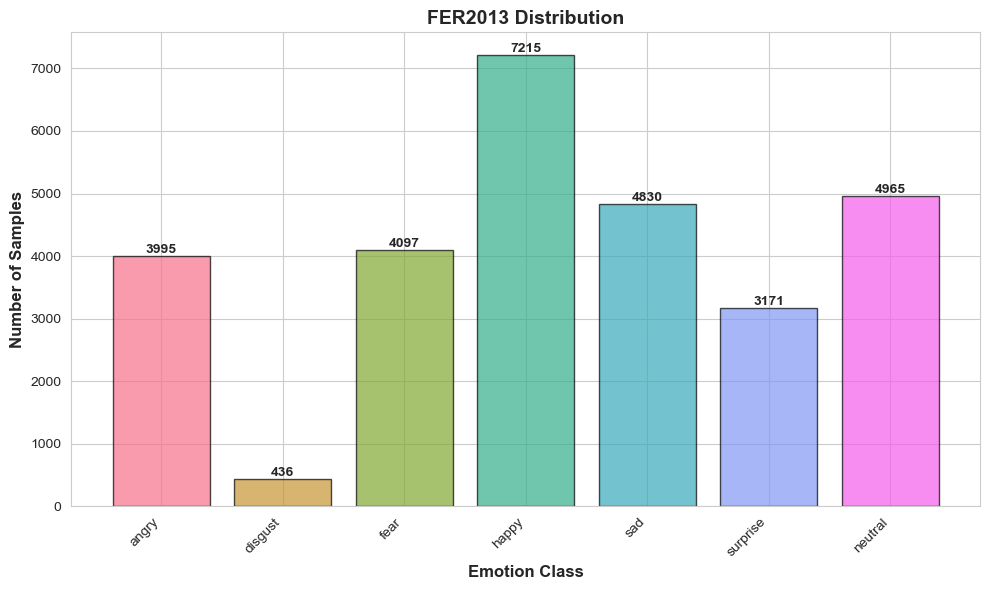

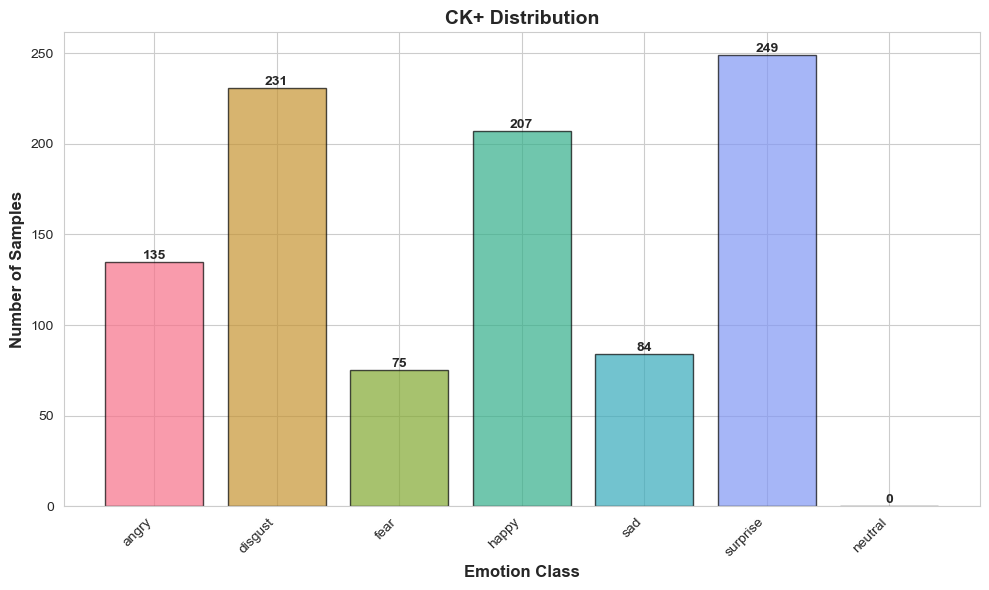

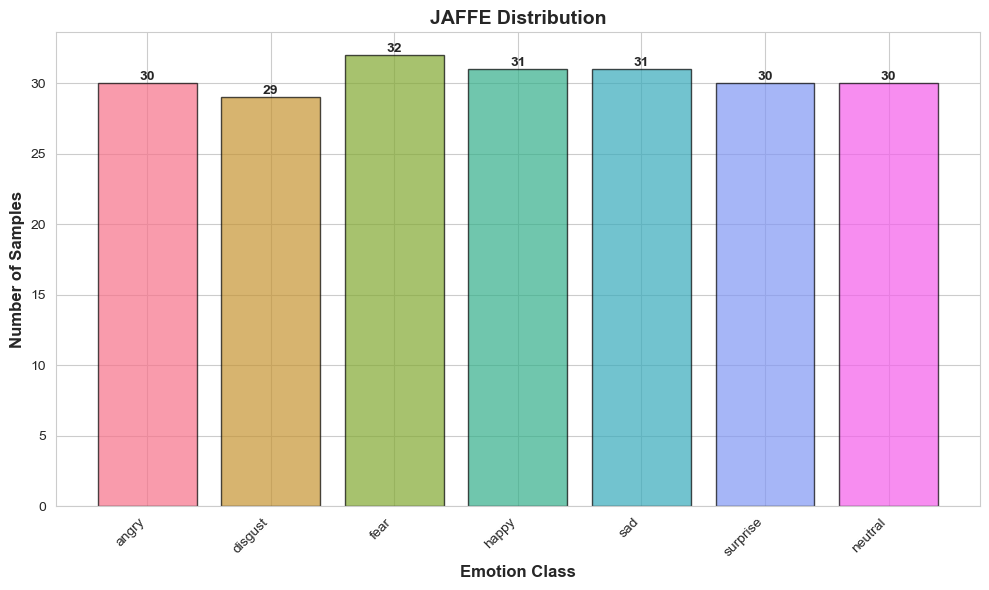

In [4]:
def get_class_distribution(dataset, emotions):
    if dataset is None:
        return {}
    labels = [label for _, label in dataset]
    return {emotions[i]: labels.count(i) for i in range(len(emotions))}

all_distributions = {}

if fer_train:
    fer_dist = get_class_distribution(fer_train, emotions)
    all_distributions['FER2013'] = fer_dist
    plot_class_distribution(fer_dist, 'FER2013 Distribution', 
                          save_path='../outputs/figures/fer2013_distribution.png')
    plt.show()

if ckplus:
    ck_dist = get_class_distribution(ckplus, emotions)
    all_distributions['CK+'] = ck_dist
    plot_class_distribution(ck_dist, 'CK+ Distribution',
                          save_path='../outputs/figures/ckplus_distribution.png')
    plt.show()

if jaffe:
    jaffe_dist = get_class_distribution(jaffe, emotions)
    all_distributions['JAFFE'] = jaffe_dist
    plot_class_distribution(jaffe_dist, 'JAFFE Distribution',
                          save_path='../outputs/figures/jaffe_distribution.png')
    plt.show()

## 3. Multi-Dataset Comparison

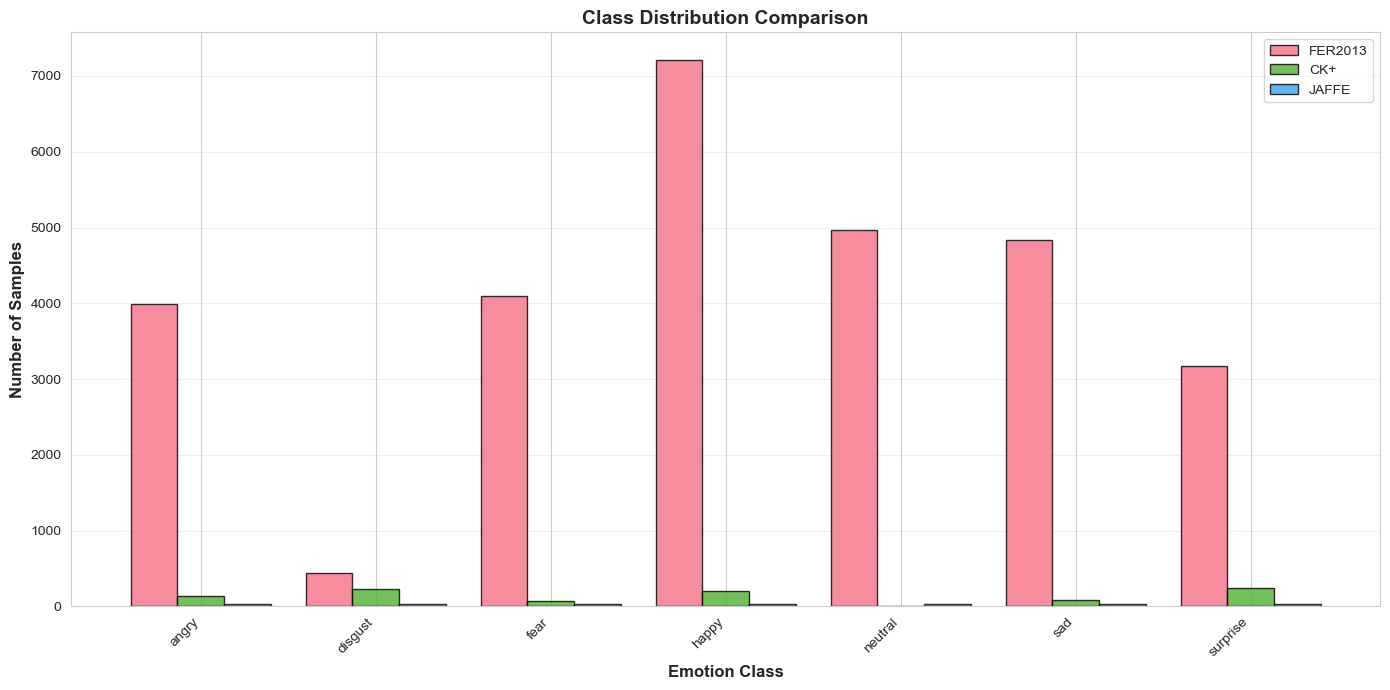

In [5]:
if all_distributions:
    plot_multi_dataset_distribution(all_distributions,
        title='Class Distribution Comparison',
        save_path='../outputs/figures/multi_dataset_distribution.png')
    plt.show()

## 4. Visualize Sample Images

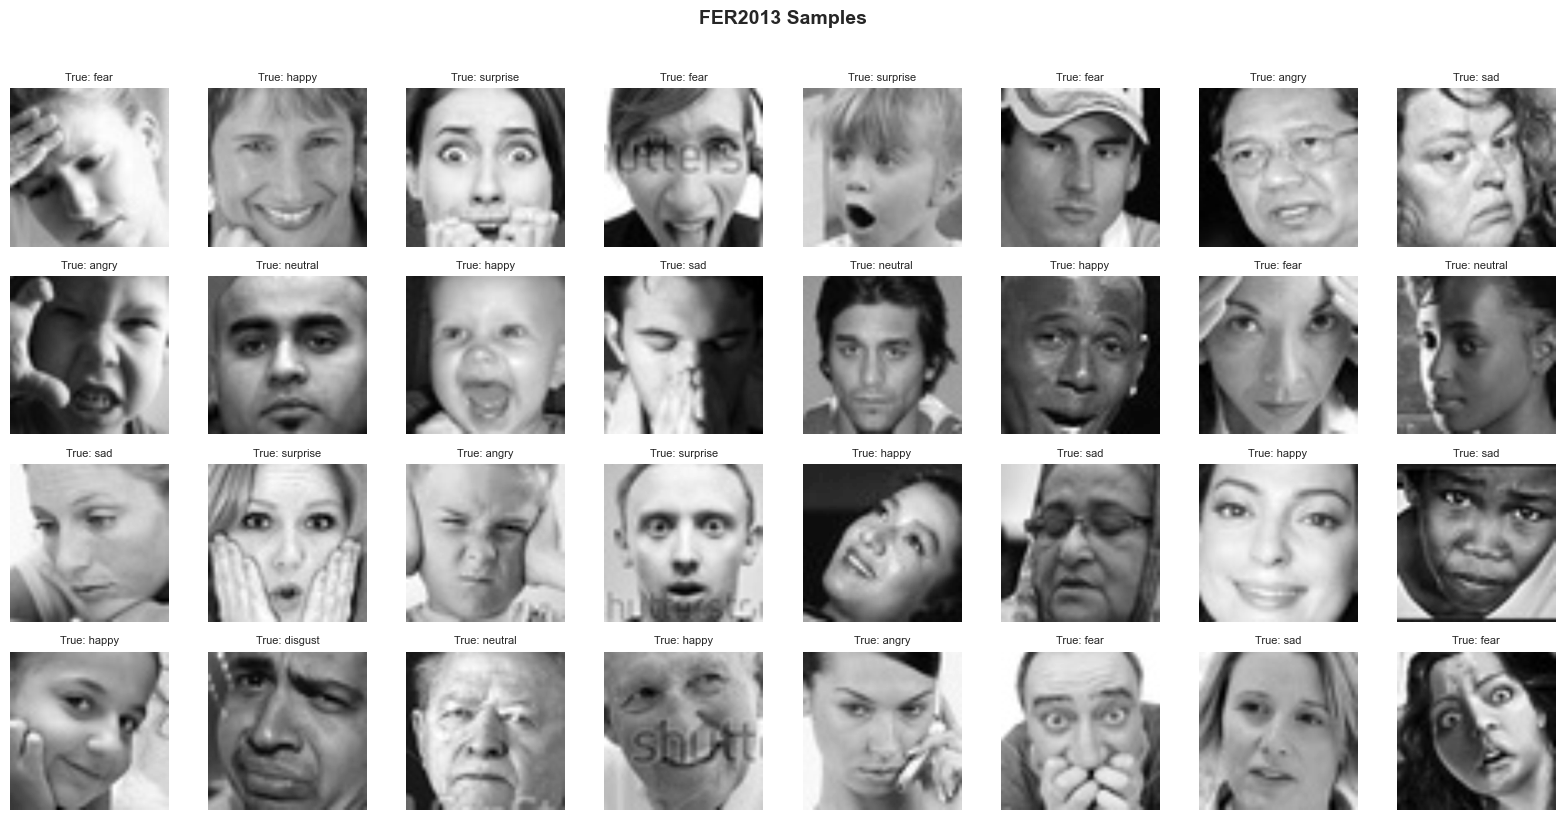

In [6]:
if fer_train:
    n_samples = 32
    indices = np.random.choice(len(fer_train), n_samples, replace=False)
    images = [fer_train.images[i] for i in indices]
    labels = [emotions[fer_train.labels[i]] for i in indices]
    plot_sample_images(images, labels, title='FER2013 Samples',
                      save_path='../outputs/figures/fer2013_samples.png',
                      grid_size=(4, 8))
    plt.show()

## 5. Image Quality Analysis

Analyzing: 100%|██████████| 1000/1000 [00:00<00:00, 2010.70it/s]


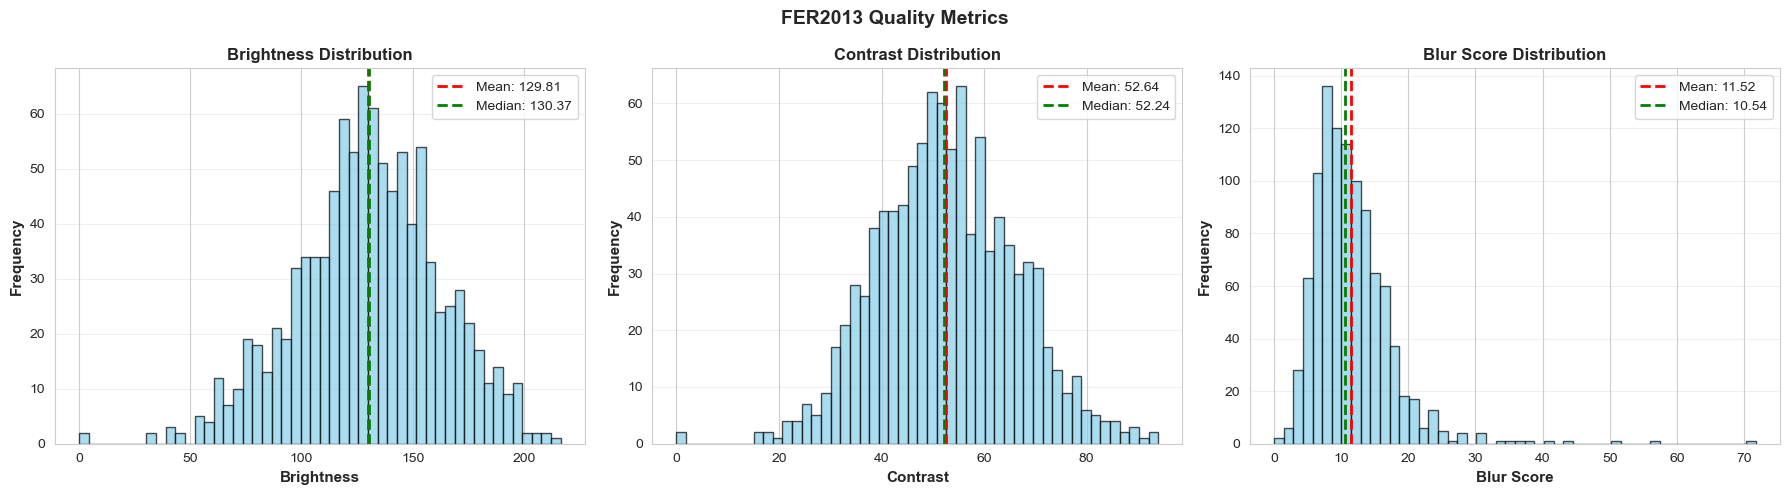

Brightness: Mean=129.81, Std=32.45
Contrast: Mean=52.64, Std=13.49
Blur Score: Mean=11.52, Std=5.90


In [7]:
def analyze_quality(images, sample_size=1000):
    if len(images) > sample_size:
        indices = np.random.choice(len(images), sample_size, replace=False)
        images = [images[i] for i in indices]
    brightness, contrast, blur = [], [], []
    for img in tqdm(images, desc='Analyzing'):
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape) == 3 else img
        brightness.append(np.mean(gray))
        contrast.append(np.std(gray))
        blur.append(cv2.Laplacian(gray, cv2.CV_64F).var())
    return {'Brightness': brightness, 'Contrast': contrast, 'Blur Score': blur}

if fer_train:
    quality = analyze_quality(fer_train.images)
    plot_quality_metrics(quality, title='FER2013 Quality Metrics',
                        save_path='../outputs/figures/fer2013_quality.png')
    plt.show()
    for metric, values in quality.items():
        print(f'{metric}: Mean={np.mean(values):.2f}, Std={np.std(values):.2f}')

## 6. Save Summary

In [8]:
summary = {'datasets': {}, 'findings': {}}
if fer_train:
    summary['datasets']['fer2013'] = {'total': len(fer_train), 'distribution': fer_dist}
if ckplus:
    summary['datasets']['ckplus'] = {'total': len(ckplus), 'distribution': ck_dist}
if jaffe:
    summary['datasets']['jaffe'] = {'total': len(jaffe), 'distribution': jaffe_dist}

with open('../outputs/reports/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✓ Phase 1 Complete!')
print('✓ Summary saved to outputs/reports/eda_summary.json')

✓ Phase 1 Complete!
✓ Summary saved to outputs/reports/eda_summary.json
